# EDA - Prediction of Poor Asthma Control

Exploratory data analysis for the project on predicting poor control in asthma patients.

**Target variable:** `poor_control` (binary: 1 = poor control, 0 = good control)

**Definition of poor control** — labeled as 1 if any of the following criteria are met:

- *Criterion 1*: use of oral corticosteroids (OCS)
- *Criterion 2*: use of magnesium sulfate
- *Criterion 3*: ICU admission or hospital admission due to asthma
- *Criterion 4*: AMR < 0.5 and/or SABA ≥ 12 dispensed inhalers

**Notebook structure:**
1. Imports and data loading
2. Preprocessing
   - 2.1 Column and value normalization
   - 2.2 Patient identifier anonymization
   - 2.3 Consolidation of variables: eosinophils and IgE
   - 2.4 Temporal feature engineering
   - 2.5 Column removal
3. Dataset overview
4. Missing data analysis
5. Variable distributions
6. Target variable imbalance
7. Univariate analysis vs poor_control
8. Mutual Information
9. Correlations
10. Export processed dataset

## 1. Imports y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import mutual_info_score

sns.set_theme(style='whitegrid')

In [2]:
df = pd.read_csv('data.csv')

## 2. Preprocessing

### 2.1 Column and Value Normalization

We standardize column names and text values: lowercase, no spaces, and no accents.

In [3]:
# Normalize column names
df.columns = df.columns.str.lower()

In [4]:
# Normalize values in ap_zone
df['ap_zone'] = (df['ap_zone']
    .str.replace(' ', '_')
    .str.replace('-', '')
    .str.replace('ń', 'n')
    .str.replace('__', '_')
    .str.lower())

In [5]:
# Normalize values in area
df['area'] = (df['area']
    .str.replace('Á', 'A')
    .str.replace(' ', '_')
    .str.lower())

### 2.2 Patient Identifier Anonymization

The cipaut column contains the regional CIP, a direct patient identifier.
It is replaced with a random anonymous integer before any analysis.

- The anonymization mapping is removed from memory after being applied and cannot be recovered.
- `random_state=42` guarantees reproducibility: the same CIP will always produce the same      anonymous ID
in each execution, which is necessary for temporal lag calculations to remain consistent.

In [6]:
np.random.seed(42)
unique_cips       = df['cipaut'].unique()
anonymized_ids      = np.random.permutation(len(unique_cips))
anonymization_map = dict(zip(unique_cips, anonymized_ids))

df['cipaut'] = df['cipaut'].map(anonymization_map)
del anonymization_map

print(f'Anonymized patients: {len(unique_cips):,}')

Anonymized patients: 53,624


### 2.3 Variable Consolidation: Eosinophils and IgE

Before calculating lags, we consolidate eosinophil and IgE thresholds into ordinal categorical variables.
This must be done **here** because the lags will be computed on `eos_nivel` and `ige_nivel`, not on the original columns.

| Variable | Categories |
|----------|------------|
| `eos_level` | `no_analitics` → `normal` → `moderate` (≥300) → `high` (≥500) → `very_high` (≥1000) |
| `ige_level` | `no_analitics` → `normal` → `high` (≥100) |

In [7]:
# Consolidate eosinophil thresholds into an ordinal categorical variable
def classify_eos(row):
    if row['eosinophils'] == 0:
        return 'no_analitics'
    elif row['eos_over_1000'] == 1:
        return 'very_high'
    elif row['eos_over_500'] == 1:
        return 'high'
    elif row['eos_over_300'] == 1:
        return 'moderate'
    else:
        return 'normal'

df['eos_level'] = df.apply(classify_eos, axis=1)

def classify_ige(row):
    if row['ige'] == 0:
        return 'no_analitics'
    elif row['ige_over_100'] == 1:
        return 'high'
    else:
        return 'normal'

df['ige_level'] = df.apply(classify_ige, axis=1)

# Remove original redundant columns
df = df.drop(columns=[
    'eosinophils', 'eos_over_300', 'eos_over_500', 'eos_over_1000',
    'ige', 'ige_over_100'
])

print('eos_level distribution:')
print(df['eos_level'].value_counts())
print()
print('ige_level distribution:')
print(df['ige_level'].value_counts())

eos_level distribution:
eos_level
no_analitics    168856
normal           80950
moderate         36424
high             16464
very_high         1789
Name: count, dtype: int64

ige_level distribution:
ige_level
no_analitics    296295
high              7878
normal             310
Name: count, dtype: int64


### 2.4 Temporal Features

We leverage the 7 years of patient history to create variables that capture temporal evolution.
These are calculated **before removing `cipaut`**, yas the identifier is needed to group by patient.

Lag and cumulative features are computed for variables that actually change over time: lab results, treatments, follow-ups, and diagnostic tests.
Chronic comorbidities are excluded for now, as they are almost constant.

**Handling gaps:** some patients do not have consecutive records for all years.
Lags are only applied when the previous year actually exists (year - previous_year == 1).
Otherwise, the value is imputed with **-1** (‘no history’), the same approach used for lab thresholds.

In [8]:
# Sort by patient and year
df = df.sort_values(['cipaut', 'year']).reset_index(drop=True)

# Create auxiliary column to detect gaps between consecutive years
df['previous_year'] = df.groupby('cipaut')['year'].shift(1)
df['valid_lag']   = df['year'] - df['previous_year'] == 1

# Numeric/binary variables: ‘no history’ value = -1
lag_vars_num = [
    'poor_control',
    'ics_laba',
    'biologic_treatment',
    'pulmonology_follow_up',
    'allergy_follow_up',
    'spirometry',
    'prick_test',
    'feno',
]

# String variables: ‘no history’ value = 'sin_historial'
lag_vars_str = [
    'eos_level',
    'ige_level',
]

for var in lag_vars_num:
    lag_col = f'{var}_lag1'
    df[lag_col] = df.groupby('cipaut')[var].shift(1)
    df.loc[~df['valid_lag'], lag_col] = -1
    df[lag_col] = df[lag_col].fillna(-1)

for var in lag_vars_str:
    lag_col = f'{var}_lag1'
    df[lag_col] = df.groupby('cipaut')[var].shift(1)
    df.loc[~df['valid_lag'], lag_col] = 'no_history'
    df[lag_col] = df[lag_col].fillna('no_history')

# Robust poor_control cumulative: reset exactly at gaps
# Iterate row by row per patient, ensuring that if lag == -1 then cumulative == -1
def acum_with_gaps(g):
    result = []
    acum = 0
    prev_year = None
    mc_prev = None
    for _, row in g.iterrows():
        if prev_year is None:
            # First record of each patient: ‘no history’
            result.append(-1)
        elif row['year'] - prev_year != 1:
            # Gap detected: reset cumulative
            result.append(-1)
            acum = 0
        else:
            result.append(acum)
        acum += mc_prev if mc_prev is not None else 0
        prev_year = row['year']
        mc_prev = row['poor_control']
    return pd.Series(result, index=g.index)

df['poor_control_acum'] = (
    df.groupby('cipaut')
    .apply(acum_with_gaps)
    .reset_index(level=0, drop=True)
)

# Years in record (0 = first year, independent of gaps)
df['years_in_record'] = df.groupby('cipaut').cumcount()

# Clean auxiliary columns
df = df.drop(columns=['previous_year', 'valid_lag'])

print(f'Temporal Features createds: {len(lag_vars_num) + len(lag_vars_str)} lags + poor_control_acum + years_in_record')
print(f'Shape: {df.shape}')

# Consistency check: poor_control_lag1 should never be -1 while poor_control_cum > 0
inconsistents = df[(df['poor_control_lag1'] == -1) & (df['poor_control_acum'] > 0)]
print(f'lag/acum Inconsistencies: {len(inconsistents)} (expected 0)')

Temporal Features createds: 10 lags + poor_control_acum + years_in_record
Shape: (304483, 65)
lag/acum Inconsistencies: 0 (expected 0)


### 2.5 Eliminación de columnas

**Data leakage** — variables that are part of the `poor_control` definition:

| Column | Reason |
|---------|--------|
| `ocs`, `magnesium_sulfate` | Criteria 1 and 2 — direct definition of poor control |
| `icu_admission`, `hospital_admission` | Criterion 3 |
| `moderate_exacerbation/severe/very_severe` | Derived from the severity of poor control |
| `emergency_visit` | Linked to the SABA ≥ 12 criterion (criterion 4) |

Confirmed in univariate analysis: risk ratios 4–6×, MI 0.16–0.43.

**Other removals:**
- `cipaut`: patient identifier — already used for temporal features
- `men_age_*` / `women_age_*`: redundant with `age` and `sex`
- `immunotherapy`: zero variance (all values = 0)

In [9]:
# Remove patient identifier
df = df.drop(columns=['cipaut'])

# Remove sex–age feature engineering columns (redundant)
cols_to_drop = [col for col in df.columns if col.startswith('men_') or col.startswith('women_')]
df = df.drop(columns=cols_to_drop)

# Remove variables causing data leakage — part of the poor_control definition:
leakage_cols = [
    'ocs',                      # Poor control 1: oral corticosteroids
    'magnesium_sulfate',        # Poor control 2: magnesium sulfate
    'icu_admission',            # Poor control 3: ICU admission
    'hospital_admission',       # Poor control 3: hospital admission
    'moderate_exacerbation',    # Derived from poor control (absence of poor control)
    'severe_exacerbation',      # Derived from poor control (poor control 2 without 3)
    'very_severe_exacerbation', # Derived from poor control (poor control 3)
    'emergency_visit',                # Linked to SABA ≥ 12 criterion (poor control 4)
]
df = df.drop(columns=leakage_cols)

# Remove immunotherapy: single value (0) in all records, no variance
df = df.drop(columns=['immunotherapy'])

print(f'Deleted columns: cipaut + {len(cols_to_drop)} sex-age + {len(leakage_cols)} leakage + immunotherapy')
print(f'Final shape: {df.shape}')

Deleted columns: cipaut + 16 sex-age + 8 leakage + immunotherapy
Final shape: (304483, 39)


## 3. Dataset Overview

In [10]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')

Rows: 304,483
Columns: 39


In [11]:
df.dtypes

area                                str
ap_zone                             str
sex                               int64
year                              int64
age                               int64
arterial_hypertension             int64
chronic_kidney_disease            int64
cardiovascular_disease            int64
obesity                           int64
heart_failure                     int64
rhinitis_sinusitis_polyposis      int64
diabetes                          int64
osteoporosis                      int64
osa                               int64
anxiety                           int64
depression                        int64
gastroesophageal_reflux           int64
spirometry                        int64
prick_test                        int64
feno                              int64
poor_control                      int64
pulmonology_follow_up             int64
allergy_follow_up                 int64
ics_laba                          int64
biologic_treatment                int64


In [12]:
# Descriptive statistics only for the continuous numeric variable
df[['age']].describe()

,age
count,304483.000000
mean,43.820735
std,20.280784
min,15.000000
25%,27.000000
50%,42.000000
75%,58.000000
max,108.000000


## 4. Missing Data Analysis

**Note on imputation:** Threshold columns (`eos_over_*`, `ige_over_100`) contain **-1** when the patient has no lab test that year (`eosinophils = 0` o `ige = 0`).
This -1 **is not a missing value**, but a clinically meaningful state: test not performed. It is valid information for the model.

In [13]:
nulls = df.isnull().sum()
pct = (nulls / len(df)) * 100
pd.DataFrame({'nulls': nulls, 'porcentage': pct}).sort_values('porcentage', ascending=False)

,nulls,porcentage
area,0,0.0
ap_zone,0,0.0
sex,0,0.0
year,0,0.0
age,0,0.0
arterial_hypertension,0,0.0
chronic_kidney_disease,0,0.0
cardiovascular_disease,0,0.0
obesity,0,0.0
heart_failure,0,0.0


## 5. Variable Distributions

The only continuous numeric variable is `age`. The rest of the variables are binary (0/1) or categorical.

Threshold variables (`eos_over_*`, `ige_over_100`) have 3 states: -1 (no lab test), 0 (does not exceed threshold), 1 (exceeds threshold).

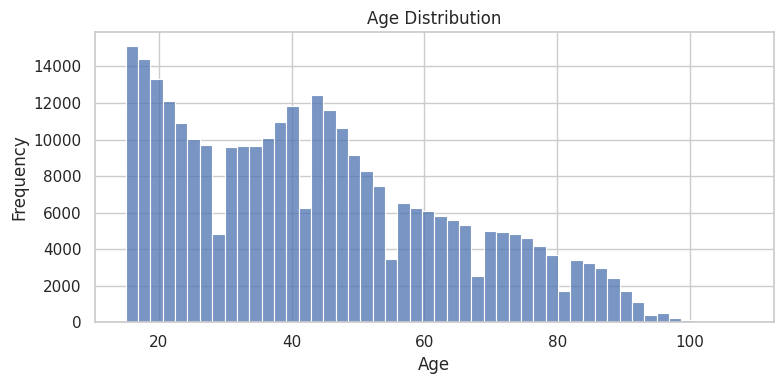

Skewness: 0.504


In [14]:
# Age histogram
# Skewness of 0.504: slight positive skew, log transformation not required
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df['age'], bins=50, ax=ax)
ax.set_title('Age Distribution')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Skewness: {df["age"].skew():.3f}')  # Close to 0 = no relevant skewness

## 6. Target Variable Imbalance

The positive class (`poor_control = 1`) represents **15.65%** of the total, with an approximate ratio of **85/15**.

This imbalance is **moderate**: aggressive techniques like SMOTE are not required. With XGBoost, it can be directly handled using `scale_pos_weight ≈ 5.4` (85/15).

Additionally, there is a **Increasing trend** in the poor control rate by year: from ~13% in 2018–2021 to ~18% in 2022–2024. This implies that the test year (2024) has a slightly different distribution than the training period, which may affect final metrics.

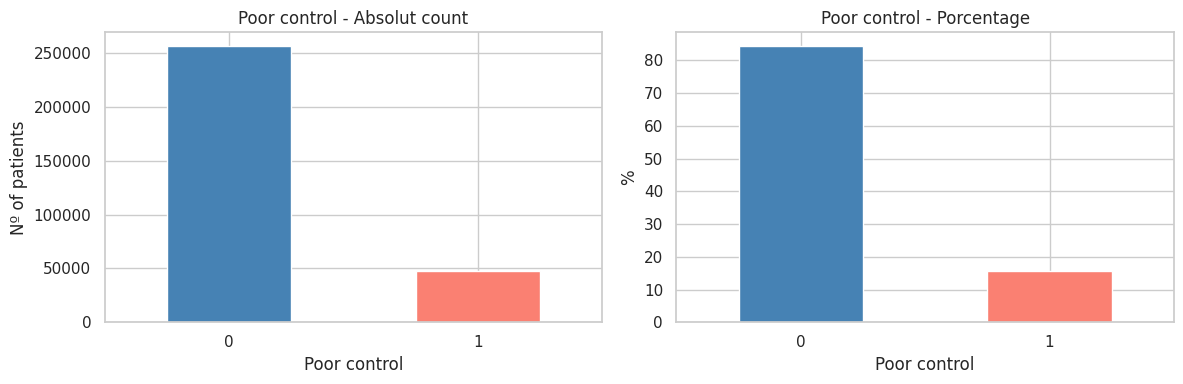

poor_control
0    84.35
1    15.65
Name: proportion, dtype: float64


In [15]:
# Global Imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['poor_control'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Poor control - Absolut count')
axes[0].set_xlabel('Poor control')
axes[0].set_ylabel('Nº of patients')
axes[0].tick_params(axis='x', rotation=0)

df['poor_control'].value_counts(normalize=True).mul(100).plot(kind='bar', ax=axes[1], color=['steelblue', 'salmon'])
axes[1].set_title('Poor control - Porcentage')
axes[1].set_xlabel('Poor control')
axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(df['poor_control'].value_counts(normalize=True).mul(100).round(2))

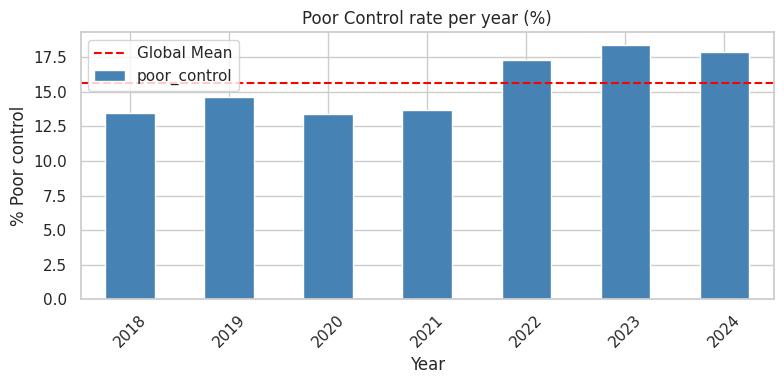

year
2018    13.44
2019    14.66
2020    13.37
2021    13.68
2022    17.28
2023    18.38
2024    17.91
Name: poor_control, dtype: float64


In [16]:
# Imbalance per year
# Note: ‘year’ is used here only for exploratory analysis, it will NOT be included as a feature in the model
rate_per_year = df.groupby('year')['poor_control'].mean().mul(100).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
rate_per_year.plot(kind='bar', ax=ax, color='steelblue')
ax.axhline(df['poor_control'].mean() * 100, color='red', linestyle='--', label='Global Mean')
ax.set_title('Poor Control rate per year (%)')
ax.set_xlabel('Year')
ax.set_ylabel('% Poor control')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print(rate_per_year)

## 7. Univariate Analysis vs `poor_control`

For each variable we calculate:
- **mean**: poor control rate in that group
- **count**: number of patients in that group
- **diff**: difference from the overall rate (positive = higher poor control than average)
- **risk**: ratio relative to the overall rate (>1 = higher risk, <1 = lower risk)

**Key findings:**
- `ige = 1` → risk 2.15: the strongest individual lab marker, though it only affects ~8k patients (2.7% of total).
- `allergy_follow_up = 1` → risk 2.36: the strongest non-lab predictor.
- `spirometry = 1` → risk 2.06: clinically consistent, patients with spirometry tend to be more severe.
- `ics_laba = 0` → risk 0.44: untreated patients have lower poor control, likely because they are mild cases that do not need treatment.
- `sex = 0` (women) → risk 1.16 vs `sexo = 1` (men) → risk 0.82: women have a higher poor control rate.
- `area` with value `-` (42 patients without assigned area) → risk 1.83

In [17]:
# Definition of variable lists
# Leakage variables and immunotherapy have already been removed from the dataframe
# ‘year’ is included only for exploratory analysis, it will not be part of the model

numerical = ['age']

categorical = [
    'area',
    'ap_zone',
    'sex',
    'year',
    'arterial_hypertension',
    'chronic_kidney_disease',
    'cardiovascular_disease',
    'obesity',
    'heart_failure',
    'rhinitis_sinusitis_polyposis',
    'diabetes',
    'osteoporosis',
    'osa',
    'anxiety',
    'depression',
    'gastroesophageal_reflux',
    'spirometry',
    'prick_test',
    'feno',
    'pulmonology_follow_up',
    'allergy_follow_up', 
    'ics_laba',
    'biologic_treatment',
    'eos_level',
    'ige_level',
    'years_in_record'
]

# List for heatmap: exclude string variables (area, ap_zone)
binary = [c for c in categorical if c not in ['area', 'ap_zone', 'eos_level', 'ige_level', 'years_in_record']]

In [18]:
global_mc = df['poor_control'].mean()
print(f'Overall poor control rate: {global_mc:.2%}')

for c in categorical:
    print(f'\n--- {c} ---')
    df_group = df.groupby(c)['poor_control'].agg(['mean', 'count'])
    df_group['diff'] = (df_group['mean'] - global_mc).round(4)
    df_group['risk'] = (df_group['mean'] / global_mc).round(3)
    display(df_group)

Overall poor control rate: 15.65%

--- area ---


,mean,count,diff,risk
area,,,,
-,0.285714,42,0.1292,1.826
area_laredo,0.172539,54324,0.0160,1.102
area_reinosa,0.164175,7425,0.0077,1.049
area_santander,0.152169,162109,-0.0043,0.972
area_torrelavega,0.153630,80583,-0.0029,0.982



--- ap_zone ---


,mean,count,diff,risk
ap_zone,,,,
,0.285714,42,0.1292,1.826
altamira,0.157016,7668,0.0005,1.003
alto_ason,0.195051,2748,0.0385,1.246
alto_pas,0.186377,2672,0.0299,1.191
astillero,0.160945,12147,0.0044,1.028
bajo_ason,0.195593,4039,0.0391,1.250
bajo_pas,0.139612,8101,-0.0169,0.892
besaya,0.154636,10418,-0.0019,0.988
bezana,0.133504,9393,-0.0230,0.853



--- sex ---


...

,mean,count,diff,risk
eos_level,,,,
high,0.230078,16464,0.0736,1.470
moderate,0.202504,36424,0.0460,1.294
no_analitics,0.107002,168856,-0.0495,0.684
normal,0.220741,80950,0.0642,1.410
very_high,0.307993,1789,0.1515,1.968



--- ige_level ---


,mean,count,diff,risk
ige_level,,,,
high,0.337141,7878,0.1806,2.154
no_analitics,0.151528,296295,-0.0050,0.968
normal,0.319355,310,0.1629,2.041



--- years_in_record ---


,mean,count,diff,risk
years_in_record,,,,
0,0.149411,53624,-0.0071,0.955
1,0.143136,49778,-0.0134,0.915
2,0.135454,46156,-0.0210,0.866
3,0.139424,43020,-0.0171,0.891
4,0.173134,40125,0.0166,1.106
5,0.185638,37433,0.0291,1.186
6,0.185431,34347,0.0289,1.185


## 8. Mutual Information

Mutual Information measures the dependency between each variable and `mal_control`, regardless of whether the relationship is linear or not. It is especially useful for binary variables where Pearson correlation is not appropriate.

The higher the value, the more information the variable provides about the target.

**Note:** After removing leakage variables (which had artificially high MI: 0.43, 0.25, 0.25, 0.16), the ranking now reflects genuine relationships with poor control.

ics_laba                        0.0373
eos_level                       0.0118
allergy_follow_up               0.0093
spirometry                      0.0088
arterial_hypertension           0.0051
ige_level                       0.0027
sex                             0.0027
obesity                         0.0026
chronic_kidney_disease          0.0024
depression                      0.0021
anxiety                         0.0021
cardiovascular_disease          0.0020
osteoporosis                    0.0019
heart_failure                   0.0017
year                            0.0016
years_in_record                 0.0014
ap_zone                         0.0013
diabetes                        0.0013
biologic_treatment              0.0012
pulmonology_follow_up           0.0011
feno                            0.0010
prick_test                      0.0008
gastroesophageal_reflux         0.0005
osa                             0.0002
area                            0.0002
rhinitis_sinusitis_polypo

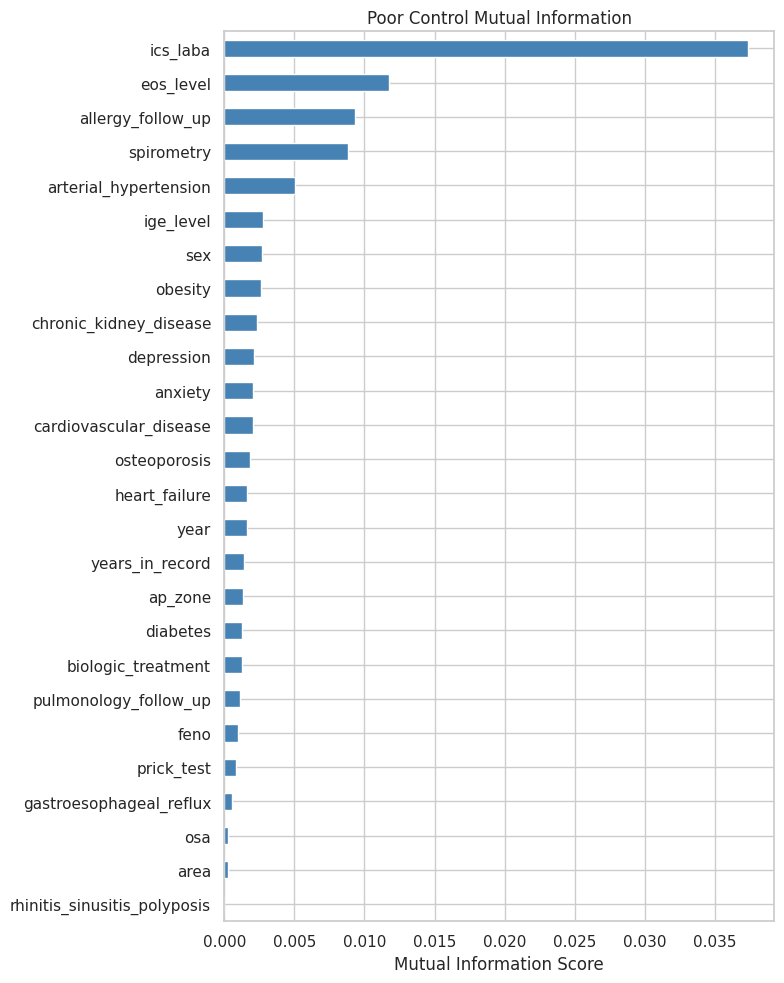

In [19]:
def mutual_info_score_fn(series):
    return mutual_info_score(series, df['poor_control'])

mi = df[categorical].apply(mutual_info_score_fn).sort_values(ascending=False)

# Tabla
print(mi.round(4))

# Visualización
fig, ax = plt.subplots(figsize=(8, 10))
mi.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Poor Control Mutual Information')
ax.set_xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

## 9. Correlations

We analyze:
1. Correlation of `age` with `poor_control` (0.148: weak but present relationship, higher age → higher risk).
2. Heatmap of all binary variables to detect redundancies before modeling.

In [20]:
# Correlation of age with poor_control
corr_age = df[numerical].corrwith(df['poor_control']).abs()
print('Correlation of numeric variables with poor_control:')
print(corr_age.round(4))

Correlation of numeric variables with poor_control:
age    0.148
dtype: float64


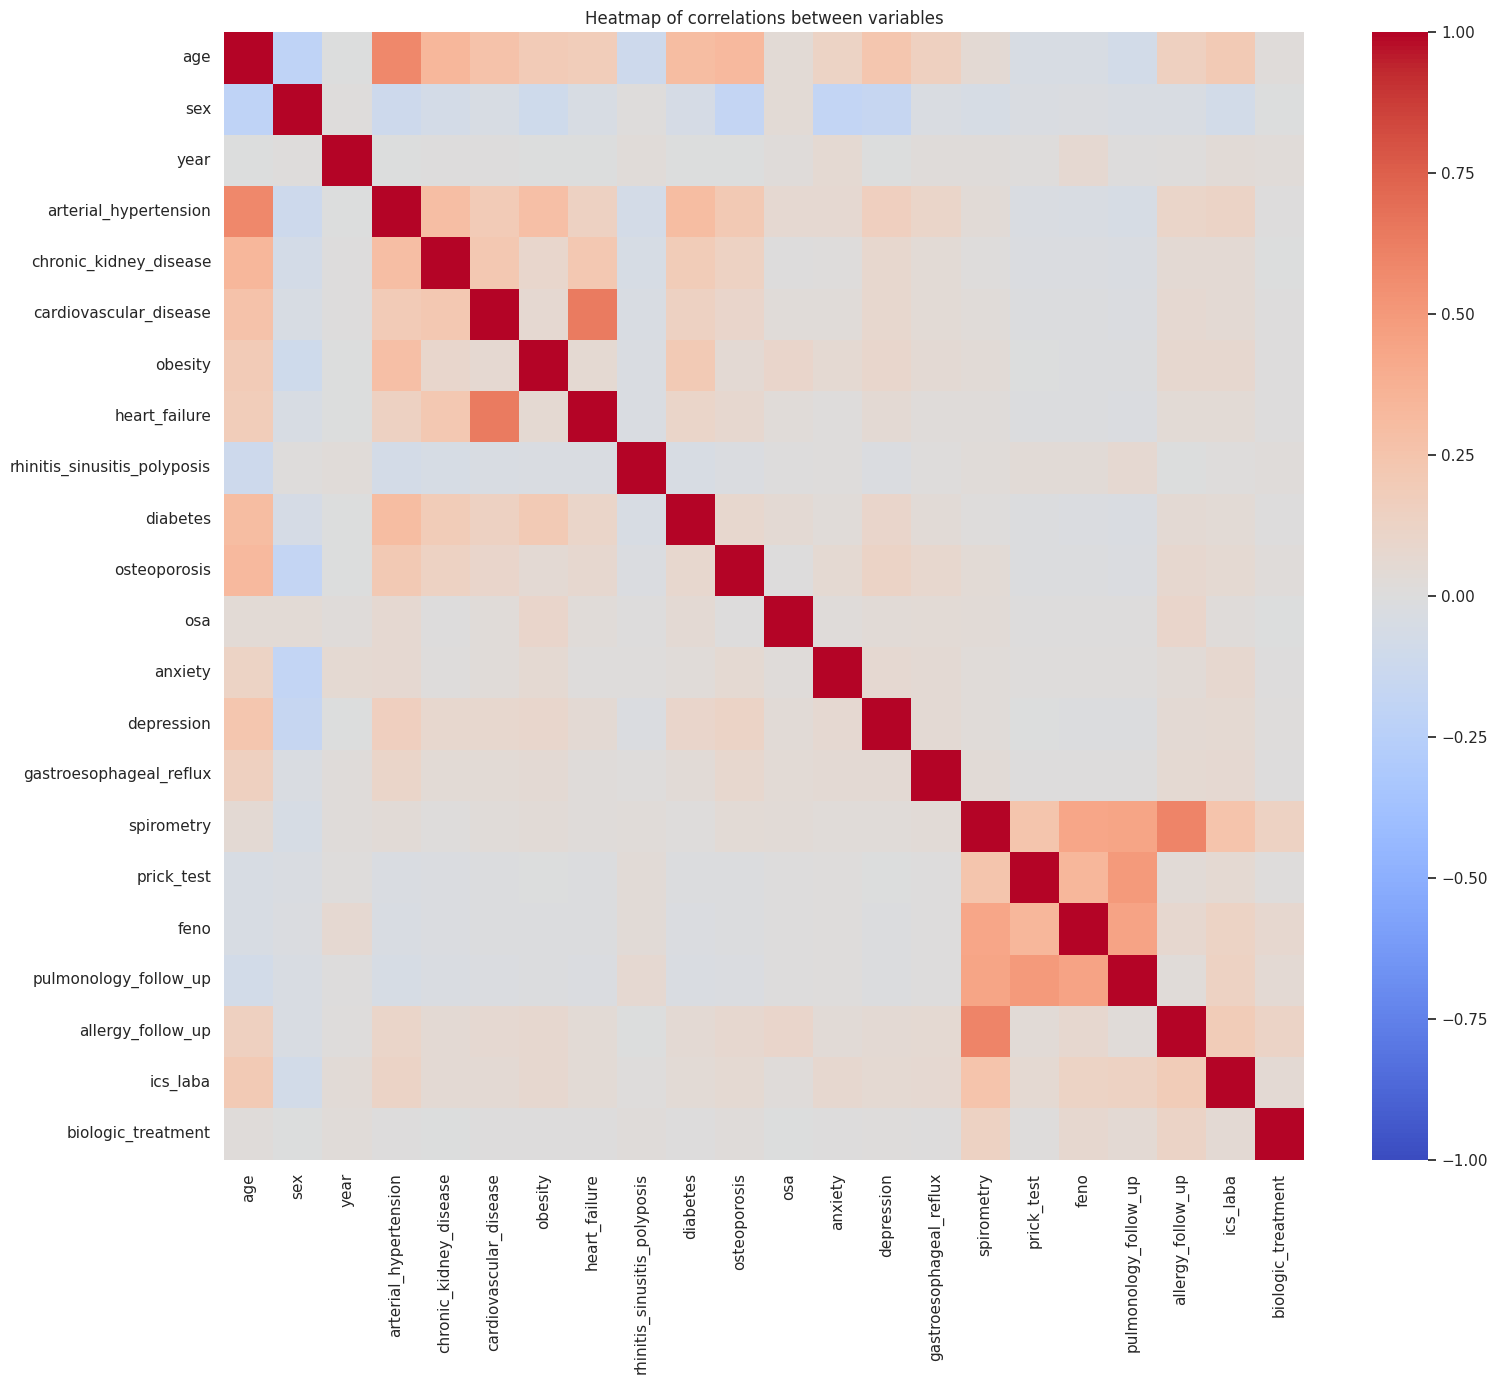

In [21]:
# Heatmap of correlations between binary variables
# Useful for detecting redundancies before training the model
corr_matrix = df[numerical + binary].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_title('Heatmap of correlations between variables')
plt.tight_layout()
plt.show()

In [22]:
df.to_csv('data_processed.csv', index=False)